#REASONING ARCHITECTURES

##0.REFERENCE AND CONTEXT

**Introduction**

The remarkable progress of modern artificial intelligence has shifted attention away from simply increasing model size toward understanding and improving reasoning itself. While early machine learning systems focused primarily on prediction, modern reasoning systems focus on how conclusions are reached. This distinction is increasingly important because many real-world decisions require complex analysis, uncertainty management, competing objectives, and structured deliberation.

Reasoning architectures provide frameworks that guide how intelligent systems process information. Different architectures produce different reasoning behaviors. Some architectures operate sequentially, others explore alternative paths, some create networks of interacting concepts, and others organize reasoning across multiple time horizons. More advanced approaches allow reasoning itself to become a compositional object that can be analyzed, stored, compared, and optimized.

This notebook introduces five reasoning architectures. Chain-of-Thought demonstrates sequential reasoning through ordered analytical steps. Tree-of-Thought expands reasoning by exploring multiple alternative branches before selecting a preferred path. Graph-of-Thought treats reasoning as a network of interconnected concepts. Multi-Timeline Reasoning analyzes decisions across multiple temporal horizons. Finally, Reasoning Molecules represent a compositional framework in which reusable reasoning components combine into higher-order cognitive structures.

The notebook uses a single financial decision problem throughout the experiment. Each architecture receives the same question and generates an independent analysis. Students can therefore directly compare the strengths and weaknesses of each reasoning framework.

The purpose of this chapter is not to identify a universally superior architecture. Instead, students learn that different reasoning architectures are appropriate for different types of problems. Sequential tasks, exploratory tasks, networked systems, temporal forecasting, and complex decision-making may all benefit from different reasoning structures.

This notebook serves as the intellectual foundation for the capstone project in Chapter 20, where multiple reasoning architectures, retrieval systems, agentic workflows, governance mechanisms, and multi-agent coordination will be integrated into a unified autonomous AI system.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the environment, creates project folders, initializes the GPT-5.2 client, and establishes reproducibility.

In [1]:
# CELL 1
# Environment Setup

!pip -q install openai networkx

import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

PROJECT_DIR = Path(
    "/content/chapter19_reasoning_architectures"
)

ARTIFACT_DIR = PROJECT_DIR / "artifacts"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUN_ID = datetime.datetime.now(
    datetime.timezone.utc
).strftime(
    "run_%Y%m%d_%H%M%S_utc"
)

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get(
        "OPENAI_API_KEY"
    )
)

MODEL_NAME = "gpt-5.2"

print("Run ID:", RUN_ID)
print("Model:", MODEL_NAME)

Run ID: run_20260606_163418_utc
Model: gpt-5.2


##2.THE DECISION PROBLEM


**Explanation for Cell 2**

This cell defines the decision problem that every reasoning architecture will analyze.

In [2]:
# CELL 2
# Decision Problem

decision_problem = """
Should a university endowment
increase its allocation to private credit
over the next five years?
"""

print(decision_problem)


Should a university endowment
increase its allocation to private credit
over the next five years?



##3.CHAIN OF THOUGHT

**Explanation for Cell 3**

This cell implements Chain-of-Thought reasoning. The model must reason sequentially through a series of analytical steps before producing a conclusion.

In [3]:
# CELL 3
# Chain-of-Thought Reasoning

cot_prompt = f"""
Use Chain-of-Thought reasoning.

Problem:

{decision_problem}

Perform:

Step 1
Step 2
Step 3
Step 4
Conclusion

Return structured JSON.
"""

cot_response = client.responses.create(
    model=MODEL_NAME,
    input=cot_prompt
)

cot_result = cot_response.output_text

print(cot_result)

```json
{
  "problem": "Should a university endowment increase its allocation to private credit over the next five years?",
  "step_1": {
    "title": "Define objectives, constraints, and decision criteria",
    "elements": {
      "endowment_objectives": [
        "Meet long-term real return target (e.g., spending rule + inflation + fees).",
        "Provide stable annual distributions to support the university budget.",
        "Preserve purchasing power across market cycles."
      ],
      "constraints": [
        "Liquidity needs (capital calls, spending, operating contingencies).",
        "Governance and operational capacity (due diligence, monitoring, manager selection).",
        "Risk limits (drawdown tolerance, credit losses, concentration, vintage risk).",
        "Policy constraints (ESG/mission alignment, regulatory/tax, leverage limits)."
      ],
      "decision_criteria": [
        "Expected net return vs. public credit and other diversifiers.",
        "Diversificatio

##4.TREE OF THOUGHT

**Explanation for Cell 4**

This cell implements Tree-of-Thought reasoning. Multiple branches are explored before selecting a preferred recommendation.

In [4]:
# CELL 4
# Tree-of-Thought Reasoning

tot_prompt = f"""
Use Tree-of-Thought reasoning.

Problem:

{decision_problem}

Create:

Branch A
Branch B
Branch C

Evaluate each branch.

Select best branch.

Return structured JSON.
"""

tot_response = client.responses.create(
    model=MODEL_NAME,
    input=tot_prompt
)

tot_result = tot_response.output_text

print(tot_result)

```json
{
  "question": "Should a university endowment increase its allocation to private credit over the next five years?",
  "time_horizon_years": 5,
  "branches": [
    {
      "id": "A",
      "name": "Increase allocation meaningfully (pro-risk/return, pro-illiquidity)",
      "thesis": "Private credit offers attractive risk-adjusted yield and diversification versus public fixed income, and can help meet spending needs; the endowment should increase exposure, leaning into manager selection and structural protections.",
      "key_arguments_for": [
        "Higher contractual income than most public IG fixed income, supportive for endowment spending.",
        "Floating-rate structures can reduce duration risk relative to long-duration bonds.",
        "Potential diversification vs public equities and traditional bonds, especially if focused on senior-secured, covenanted lending.",
        "Bank retrenchment and regulatory constraints can sustain private lenders’ opportunity set (mi

##5.GRAPH OF THOUGHTS

**Explanation for Cell 5**

This cell implements Graph-of-Thought reasoning. The decision is analyzed as an interconnected network of concepts.

In [5]:
# CELL 5
# Graph-of-Thought Reasoning

got_prompt = f"""
Use Graph-of-Thought reasoning.

Problem:

{decision_problem}

Analyze interactions among:

Macroeconomics
Liquidity
Risk
Governance
Portfolio Construction

Describe the network of influences.

Return structured JSON.
"""

got_response = client.responses.create(
    model=MODEL_NAME,
    input=got_prompt
)

got_result = got_response.output_text

print(got_result)

```json
{
  "question": "Should a university endowment increase its allocation to private credit over the next five years?",
  "scope": {
    "time_horizon_years": 5,
    "asset_class_definition": "Private credit (direct lending, opportunistic credit, mezzanine, specialty finance; mostly illiquid, often floating-rate, covenant packages vary; manager-driven underwriting and workout).",
    "endowment_context": "Long-horizon, spending rule, multi-asset portfolio; constraints include liquidity for annual payout, capital calls, and potential drawdowns."
  },
  "graph_of_thought": {
    "nodes": [
      {
        "id": "MACRO",
        "label": "Macroeconomics",
        "description": "Growth, inflation, policy rates, credit cycle, default environment, bank retrenchment/regulation, refinancing walls."
      },
      {
        "id": "LIQ",
        "label": "Liquidity",
        "description": "Ability to meet spending/payout, capital calls, rebalancing needs, and stressed-market liquidity; lo

##6.MULTI TIMELINE REASONING

**Explanation for Cell 6**

This cell implements Multi-Timeline Reasoning. The decision is evaluated across multiple temporal horizons.

In [6]:
# CELL 6
# Multi-Timeline Reasoning

timeline_prompt = f"""
Use Multi-Timeline Reasoning.

Problem:

{decision_problem}

Analyze:

Micro Horizon
Short Horizon
Medium Horizon
Long Horizon
Macro Horizon

Return structured JSON.
"""

timeline_response = client.responses.create(
    model=MODEL_NAME,
    input=timeline_prompt
)

timeline_result = timeline_response.output_text

print(timeline_result)

```json
{
  "question": "Should a university endowment increase its allocation to private credit over the next five years?",
  "answer_summary": {
    "recommendation": "Conditionally increase",
    "recommended_direction": "Increase allocation modestly and deliberately, not aggressively",
    "base_case_rationale": "Private credit can improve income and diversification versus public fixed income and may offer an illiquidity premium, but outcomes are highly manager/structure-dependent and sensitive to credit-cycle and refinancing risk over a 5-year window.",
    "key_conditions": [
      "Endowment has sufficient liquidity (spending + capital calls) and can tolerate gating/extension risk",
      "Access to top-quartile managers and strong underwriting/monitoring capabilities",
      "Portfolio already has adequate public liquidity and crisis rebalancing capacity",
      "Allocation is implemented with vintage and strategy diversification and conservative leverage"
    ]
  },
  "time_ho

##7.REASONING MOLECULES AND REASONING ATOMS

**Explanation for Cell 7**

This cell constructs a Reasoning Molecule using reasoning atoms inspired by compositional reasoning frameworks.

In [7]:
# CELL 7
# Reasoning Molecule Builder

molecule_prompt = f"""
Build a Reasoning Molecule.

Problem:

{decision_problem}

Available Atoms:

OBS
FUND
RISK
LIQ
GOV
SYNTH
DECISION

Construct a molecule using these atoms.

Explain:

Atom Roles
Molecule Structure
Final Recommendation

Return structured JSON.
"""

molecule_response = client.responses.create(
    model=MODEL_NAME,
    input=molecule_prompt
)

molecule_result = molecule_response.output_text

print(molecule_result)

```json
{
  "molecule_id": "endowment_private_credit_allocation_5yr_v1",
  "problem": "Should a university endowment increase its allocation to private credit over the next five years?",
  "atoms": [
    {
      "type": "OBS",
      "role": "Establish current state: market conditions, endowment profile, and private credit landscape likely over the next 5 years.",
      "inputs": [
        "Current endowment objectives (spending rule, real-return target, inflation sensitivity)",
        "Current asset allocation and existing private market exposures (PE/VC/RE, private credit)",
        "Private credit market trends: spreads vs public credit, covenant quality, default cycle positioning",
        "Forward-looking rate environment uncertainty and refinancing wall dynamics",
        "Manager dispersion and capacity constraints"
      ],
      "outputs": [
        "Baseline facts and forecasts (ranges) relevant to private credit opportunity set and constraints"
      ]
    },
    {
      "ty

##8.COMPARISON OF REASONING ARCHITECTURES

**Explanation for Cell 8**

This cell compares all reasoning architectures and summarizes their recommendations.

In [8]:
# CELL 8
# Architecture Comparison

comparison_prompt = f"""
Compare these reasoning architectures.

Chain of Thought:
{cot_result}

Tree of Thought:
{tot_result}

Graph of Thought:
{got_result}

Multi-Timeline:
{timeline_result}

Reasoning Molecule:
{molecule_result}

Compare:

Strengths
Weaknesses
Recommendation Quality

Return structured JSON.
"""

comparison_response = client.responses.create(
    model=MODEL_NAME,
    input=comparison_prompt
)

comparison_result = comparison_response.output_text

print(comparison_result)

```json
{
  "comparison": {
    "Chain_of_Thought": {
      "strengths": [
        "Clear, linear decision workflow (objectives/constraints → forward-looking case → portfolio fit → implementation).",
        "Strong emphasis on endowment-specific gating items (liquidity stress tests, governance capacity, role clarity).",
        "Actionable implementation guidance (manager selection, terms, risk limits, monitoring).",
        "Good at communicating a committee-ready narrative with interim takeaways."
      ],
      "weaknesses": [
        "Path-dependence: a linear flow can underweight interactions/feedback (e.g., macro ↔ liquidity ↔ portfolio actions).",
        "Often converges to a single synthesis; alternative policies (increase/hold/decrease) are not explicitly explored as competing options.",
        "Can read as comprehensive while still relying on qualitative judgments (e.g., “adequate illiquidity premium”) without an explicit scoring/decision rule."
      ],
      "recommendat

##9.META REASONING AGENT

**Explanation for Cell 9**

This cell implements a Meta-Reasoning Agent that evaluates the quality of the reasoning architectures themselves.

In [9]:
# CELL 9
# Meta-Reasoning Agent

meta_prompt = f"""
You are a Meta-Reasoning Agent.

Evaluate:

Chain-of-Thought
Tree-of-Thought
Graph-of-Thought
Multi-Timeline Reasoning
Reasoning Molecules

Results:

{comparison_result}

Determine:

Most Transparent
Most Flexible
Most Robust
Most Suitable for Finance

Return structured JSON.
"""

meta_response = client.responses.create(
    model=MODEL_NAME,
    input=meta_prompt
)

meta_result = meta_response.output_text

print(meta_result)

```json
{
  "most_transparent": {
    "approach": "Reasoning_Molecule",
    "why": [
      "Highest traceability: modular atoms with explicit inputs/outputs make assumptions, owners, and handoffs auditable.",
      "Clear accountability mapping (e.g., CIO/risk/ops/consultant) improves decision provenance and governance transparency.",
      "Easier to document and defend to an IC/board than more abstract interaction graphs."
    ],
    "runner_up": "Tree_of_Thought"
  },
  "most_flexible": {
    "approach": "Graph_of_Thought",
    "why": [
      "Handles changing problem structure well by adding/removing nodes/edges without reworking the whole logic.",
      "Naturally incorporates new constraints, feedback loops, and regime shifts (macro ↔ liquidity ↔ portfolio actions).",
      "Modular extension points for quantitative inserts (stress tests, factor models, optimization) at specific nodes."
    ],
    "runner_up": "Reasoning_Molecule"
  },
  "most_robust": {
    "approach": "Graph_of

##10.RELATIONSHIPS AMONG REASONING ARCHITECRURES

**Explanation for Cell 10**

This cell visualizes the relationships among the reasoning architectures.

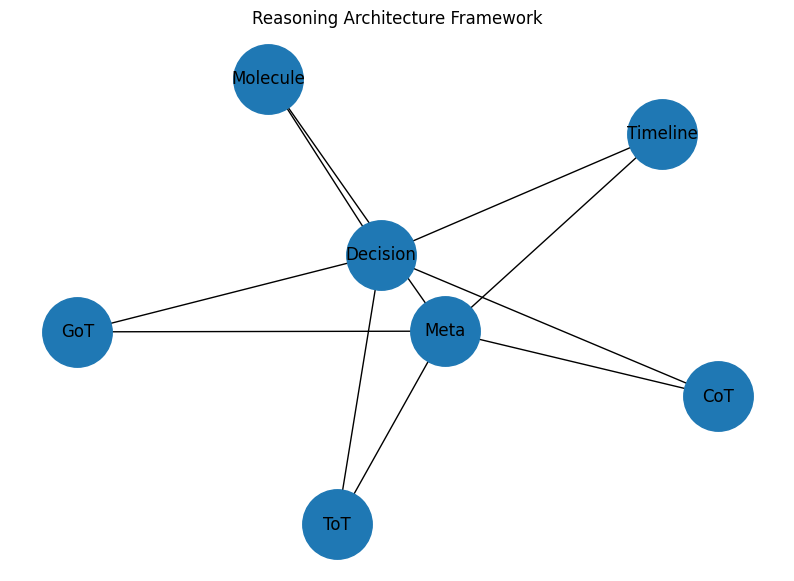

In [10]:
# CELL 10
# Reasoning Architecture Visualization

G = nx.Graph()

nodes = [
    "Decision",
    "CoT",
    "ToT",
    "GoT",
    "Timeline",
    "Molecule",
    "Meta"
]

for node in nodes:
    G.add_node(node)

edges = [
    ("Decision","CoT"),
    ("Decision","ToT"),
    ("Decision","GoT"),
    ("Decision","Timeline"),
    ("Decision","Molecule"),
    ("CoT","Meta"),
    ("ToT","Meta"),
    ("GoT","Meta"),
    ("Timeline","Meta"),
    ("Molecule","Meta")
]

G.add_edges_from(edges)

plt.figure(
    figsize=(10,7)
)

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_size=2500
)

plt.title(
    "Reasoning Architecture Framework"
)

plt.axis("off")
plt.show()

##11.SUMMARY AND EXPLANATIONS

In [ ]:
# CELL 11
# GPT-5.2 Reflection

summary = {
    "decision_problem": decision_problem,
    "architectures": [
        "Chain-of-Thought",
        "Tree-of-Thought",
        "Graph-of-Thought",
        "Multi-Timeline",
        "Reasoning Molecules"
    ]
}

reflection_prompt = f"""
Explain the significance of reasoning architectures.

Return strict JSON.

{json.dumps(summary, indent=2)}
"""

reflection_response = client.responses.create(
    model=MODEL_NAME,
    input=reflection_prompt
)

print(
    reflection_response.output_text
)

##12.CO